# Binary Search Trees

In [3]:
%pip install networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
class BST:
    class Node:
        def __init__(self, key, value):
            self.key = key
            self.value = value
            self.parent = None
            self.left = None
            self.right = None

    def __init__(self):
        self.root = None

    def inorder_tree_walk(self):
        self._inorder_tree_walk(self.root)
    
    def _inorder_tree_walk(self, node=None):
        if node is not None:
            self._inorder_tree_walk(node.left)
            print(f"({node.key}:{node.value})", end=" ")
            self._inorder_tree_walk(node.right)

    def search(self, k):
        node = self.root
        while node is not None:
            if node.key == k:
                return node
            elif node.key > k:
                node = node.left
            else:
                node = node.right
        return None # no node with key k in tree

    def minimum(self):
        return self._minimum(self.root)
    
    def _minimum(self, node):
        while node.left is not None:
            node = node.left
        return node

    def maximum(self):
        return self._maximum(self.root)
        
    def _maximum(self, node):
        while node.left is not None:
            node = node.right
        return node

    def successor(self, node):
        if node.right is not None:
            # return left-most node in right subtree
            return self._minimum(node.right)
        # otherwise, we must go upwards in the tree
        parent = node.parent
        while parent is not None and node == parent.right:
            node = parent
            parent = node.parent
        return parent

    def predecessor(self, node):
        if node.left is not None:
            # return right-most node in left subtree
            return self._maximum(node.left)
        # otherwise, we must go upwards in the tree
        parent = node.parent
        while parent is not None and node == parent.left:
            node = parent
            parent = node.parent
        return parent
    
    def insert(self, key, value):
        current = self.root
        parent = None
        # search for the right position
        while current is not None:
            parent = current
            if current.key > key:
                current = current.left
            else:
                current = current.right
        # insert the new node
        node = BST.Node(key, value)
        node.parent = parent
        if parent is None: # tree was empty
            self.root = node
        elif key < parent.key:
            parent.left = node
        else:
            parent.right = node

    def _transplant(self, u, v):
        # Replace subtree rooted at u with subtree rooted at v.
        # Also works if v is None.
        if u.parent is None:
            self.root = v
        elif u == u.parent.left:
            u.parent.left = v
        else:
            u.parent.right = v
        if v is not None:
            v.parent = u.parent
            
    def delete(self, node):
        if node.left is None:
            # Case 1 and case 2, where single child is right child.
            self._transplant(node, node.right)
        elif node.right is None:
            # Case 2, where single child is right child.
            self._transplant(node, node.left)
        else: # Case 3
            minimum = self._minimum(node.right)
            if node.right != minimum:
                # remove minimum from right subtree
                # (replacing it by its right child),
                # make this subtree the right child
                # of minimum.
                self._transplant(minimum, minimum.right)
                minimum.right = node.right
                node.right.parent = minimum
            # minimum takes over place of node with
            # left subtree of node as left subtree
            self._transplant(node, minimum)
            minimum.left = node.left
            minimum.left.parent = minimum
    
    def draw(self, only_keys=False): # for drawing; you do not need to understand this code.
        def visit(node, depth=0):
            if node is None:
                return None
            left = visit(node.left, depth+1)
            node_no = next(counter)
            if only_keys:
                labels[node_no] = f"{node.key}"
            else:
                labels[node_no] = f"{node.key}: {node.value}"
            graph.add_node(node_no, depth=depth)
            right = visit(node.right, depth+1)
            if left is not None:
                graph.add_edge(node_no, left)
            if right is not None:
                graph.add_edge(node_no, right)
            return node_no
            
        from itertools import count
        counter = count() # for assigning numbers to nodes
        labels = {}
        graph = nx.Graph()
        visit(self.root)
        # done creating the networkx graph

        pos = {node: (node, -graph.nodes[node]["depth"])
              for node in graph.nodes}
        nx.draw(graph, pos=pos, labels=labels, with_labels = True, node_size=1600, node_color='#ffffff')

        

Let us first create and draw an example binary search tree (discussing the details of insertion later):

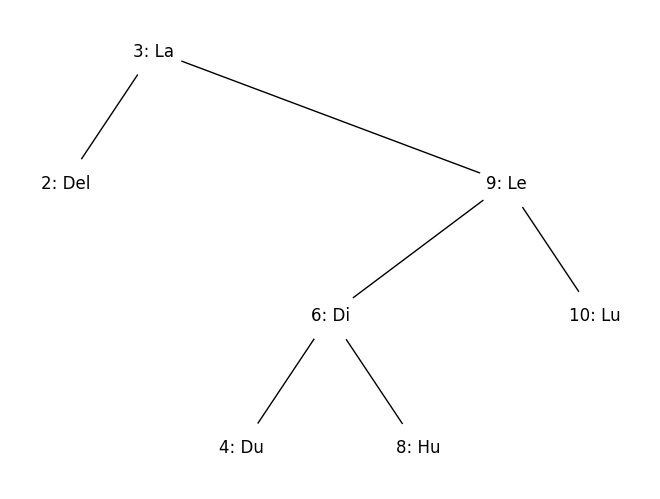

In [5]:
bst = BST()
bst.insert(3, "La")
bst.insert(9, "Le")
bst.insert(10, "Lu")
bst.insert(6, "Di")
bst.insert(2, "Del")
bst.insert(4, "Du")
bst.insert(8, "Hu")
bst.draw()

An inorder tree walk prints the keys (and their values) in sorted order:

In [6]:
bst.inorder_tree_walk()

(2:Del) (3:La) (4:Du) (6:Di) (8:Hu) (9:Le) (10:Lu) 

#### Search 
Let's try the search:

In [7]:
node = bst.search(4) # successful search
print(node.value)

Du


In [8]:
node = bst.search(7) # unsuccessful search
print(node)

None


#### Minimum and maximum

We can also query the minimum:

In [9]:
node = bst.minimum()
if node is not None:
    print(node.key, node.value)

2 Del


**Exercise:** Implement `maximum`.

#### Successor and predecessor

Let's identify successors:

In [10]:
for key in (3,8):
    start_node = bst.search(key)
    node = bst.successor(start_node)
    print("The successor (key) of", key, "is", node.key)


The successor (key) of 3 is 4
The successor (key) of 8 is 9


**Exercise:** Implement `predecessor`.

#### Insertion
We already created a binary search tree by subsequently inserting nodes:

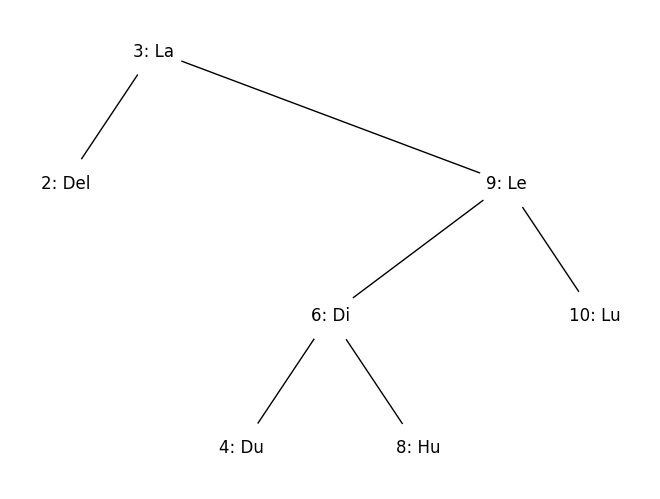

In [11]:
bst = BST()
bst.insert(3, "La")
bst.insert(9, "Le")
bst.insert(10, "Lu")
bst.insert(6, "Di")
bst.insert(2, "Del")
bst.insert(4, "Du")
bst.insert(8, "Hu")
bst.draw()

It can happen, that the tree degenerates to a chain of nodes:

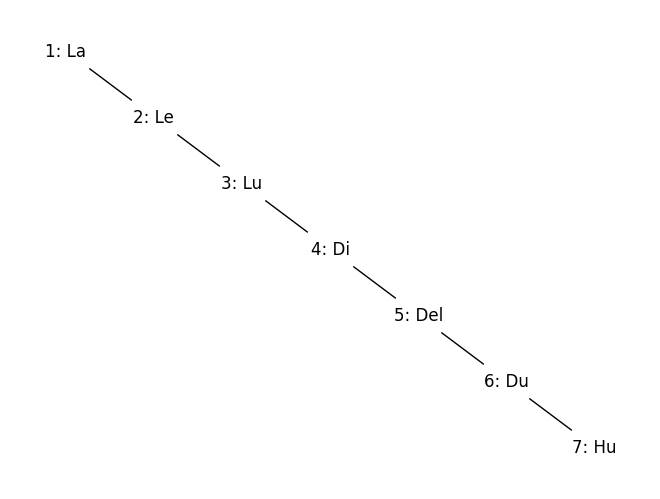

In [12]:
bst = BST()
bst.insert(1, "La")
bst.insert(2, "Le")
bst.insert(3, "Lu")
bst.insert(4, "Di")
bst.insert(5, "Del")
bst.insert(6, "Du")
bst.insert(7, "Hu")
bst.draw()

**Question:** Why is this a problem?

#### Deletion
Let's start again from a slightly more balanced binary search tree.

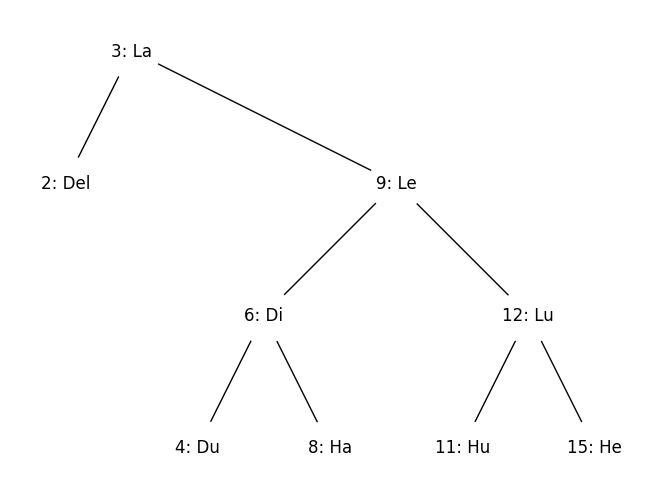

In [13]:
bst = BST()
bst.insert(3, "La")
bst.insert(9, "Le")
bst.insert(12, "Lu")
bst.insert(6, "Di")
bst.insert(2, "Del")
bst.insert(4, "Du")
bst.insert(8, "Ha")
bst.insert(15, "He")
bst.insert(11, "Hu")
bst.draw()

**Exercise:** In the following three cells, trigger each case of the deletion with a suitable key. Does the resulting tree look like you expected it?

In [14]:
key = TODO # key that leads to case 3 of deletion
node = bst.search(key)
bst.delete(node)
bst.draw()

NameError: name 'TODO' is not defined

In [ ]:
key = ... # key that leads to case 2 of deletion
node = bst.search(key)
bst.delete(node)
bst.draw()

In [ ]:
key = ... # key that leads to case 1 of deletion
node = bst.search(key)
bst.delete(node)
bst.draw()